# Run this first !
Ensures correct libraries and imports data

In [1]:

# Run this first !
# project setup — run first, do not edit except NAME
NAME = "rachel" # <<< your name

import sys, subprocess, pathlib
IN_COLAB = "google.colab" in sys.modules
REPO = "boe-financial-analysis"

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    if not pathlib.Path(f"/content/{REPO}").exists():
        subprocess.run(["git", "clone", "-q",
                        f"https://github.com/maybebool/{REPO}.git",
                        f"/content/{REPO}"], check=True)
    ROOT = pathlib.Path(f"/content/{REPO}")
    DATA = pathlib.Path("/content/drive/MyDrive/boe-data")
else:
    ROOT = pathlib.Path.cwd()
    while not (ROOT / "requirements.txt").exists() and ROOT != ROOT.parent:
        ROOT = ROOT.parent
    DATA = ROOT / "data"

sys.path.insert(0, str(ROOT))
subprocess.run(["git", "-C", str(ROOT), "fetch", "-q", "origin"], check=False)
subprocess.run(["git", "-C", str(ROOT), "merge", "-q", "origin/main", "-m", "sync"],
               check=False)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r",
                str(ROOT / "requirements.txt")], check=True)

from notebooks.env_cell import verify, check_python
check_python()
try:
    verify(ROOT)
except RuntimeError as e:
    print(e)
    print("\n Runtime -> Restart session, then run this cell again.")
    raise

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from src import loading

print(f"ok  python {sys.version.split()[0]}  pandas {pd.__version__}  data {DATA}")
print(loading.exports(DATA))
print(loading.files(DATA))

utt = loading.load(DATA, "all_utterances.csv", "2026-09-23")
sent = loading.load(DATA, "all_sentences.csv", "2026-09-23")
met = loading.load(DATA, "all_metrics.csv", "2026-09-23")

print(utt.shape, sent.shape, met.shape)
sent.head()
data=sent.copy()

ok  python 3.12.13  pandas 2.2.3  data /Users/rdrobinson/Cambridge/boe-financial-analysis/data
['2026-09-13', '2026-09-23']
['all_metrics.csv', 'all_sentences.csv', 'all_utterances.csv']
loaded all_utterances.csv  1201 rows
loaded all_sentences.csv  9519 rows
loaded all_metrics.csv  510 rows
(1201, 11) (9519, 12) (510, 6)


# Sentence pre-processing (stop words, speaker names and greetings etc)
This is just a starting point as there are several oddities - for example greeting words mean the Bert Emotion skews towards "Joy" and some stopwords such as "us" seems to be treated as a plural of "u" - hence needs removing. Also need to work out how to differentiate between "credit" and "Credit Suisse" as both are valid but cannot be treated as the same

### Import ntlk

In [2]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import re

# Download necessary NLTK data
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/rdrobinson/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/rdrobinson/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/rdrobinson/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/rdrobinson/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

### Speaker Names
Need to remove these from the sentences

In [3]:
# Create a list using "speaker_name" column from the dataframe
speaker_names = data["speaker_name"].tolist()
# Reduce list to contain only unique speaker names
speaker_names = list(set(speaker_names))
# Split first and last names of the speakers
speaker_names_split = [name.split() for name in speaker_names]
# remove capital letters from speaker names
speaker_names_split = [[name.lower() for name in sublist] for sublist in speaker_names_split]
speaker_names_split[:10]

[['nicolas', 'payen'],
 ['jeremy', 'barnum'],
 ['matt', "o'connor"],
 ['amit', 'goel'],
 ['sarah', 'mackey'],
 ['adam', 'terelak'],
 ['sergio', 'p.', 'ermotti'],
 ['glenn', 'schorr'],
 ['saul', 'martinez'],
 ['scott', 'siefers']]

### Pre-processing Function

In [4]:
def preprocess_text(text):
    if not isinstance(text, str): # Handle non-string input, e.g., NaN
        return []
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation and special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenize the text
    tokens = word_tokenize(text)

    # Remove stopwords and lemmatize
    stop_words = set(stopwords.words('english'))

    # Remove words that are not informative for topic modeling
    stop_words.update(['also', 'quarter', 'year', 'u', 'think', 'thats'])

    # Remove speaker names from the text
    speaker_names_flat = [name for sublist in speaker_names_split for name in sublist]
    

    greeting_words = {
    "hello", "hi", "dear", "greetings",
    "thank", "thanks", "good", "morning",
    "afternoon", "evening",
    "ladies", "gentlemen", "sir", "madam",
    "yeah", "welcome",
    "mr", "mrs", "ms"
}

    lemmatizer = WordNetLemmatizer()
    cleaned_tokens = [
        lemmatizer.lemmatize(word) for word in tokens
        if word not in stop_words and word.isalpha() and word not in greeting_words and word not in speaker_names_flat # Ensure only alphabetic words are kept and remove greeting words and speaker names
    ]
    return [word for word in cleaned_tokens if word not in stop_words]

In [5]:
# Apply the preprocessing function
data['cleaned_text'] = data['sentence'].apply(preprocess_text)

# Display the first few rows
print(data[['sentence', 'cleaned_text']].head(10))

                                            sentence  \
0                Good morning, ladies and gentlemen.   
1  Welcome to JPMorgan Chase’s First Quarter 2023...   
2                       This call is being recorded.   
3  Your line will be muted for the duration of th...   
4           We will now go live to the presentation.   
5                                   Please stand by.   
6  At this time, I would like to turn the call ov...   
7                       Mr. Barnum, please go ahead.   
8                Thanks, and good morning, everyone.   
9  The presentation is available on our website, ...   

                                        cleaned_text  
0                                                 []  
1           [jpmorgan, chase, first, earnings, call]  
2                                   [call, recorded]  
3                      [line, muted, duration, call]  
4                           [go, live, presentation]  
5                                    [please, stand] 

# UBS Data

In [6]:
# Create dataframe with bank = ubs
ubs_data = data[data['bank'] == 'UBS'].copy()
print(ubs_data.shape)
ubs_data.head(2)

(4714, 13)


,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,sentence_number,sentence,cleaned_text
4805,UBS,2023-Q1,earnings,2023-04-25,1,prepared,management,Sergio P. Ermotti,NaN,14594,1,"Thank you, Sarah, good morning, everyone.",[everyone]
4806,UBS,2023-Q1,earnings,2023-04-25,1,prepared,management,Sergio P. Ermotti,NaN,14595,2,I am happy to be back here with all of you.,"[happy, back]"


## Bert Emotion: All sections

Truncation = True means only 512 tokens (350 -400 words) are kept. Anything longer is ignored. Also output contains top_k = None so that the scores for all the emotions are retained to allow comparison later on

In [7]:
# Conduct Bert Emotion analysis on cleaned sentences from presentation section (UBS)
from transformers import pipeline
emotion_analyzer = pipeline("text-classification", model="bhadresh-savani/bert-base-uncased-emotion")
documents = (
    ubs_data["cleaned_text"]
    .apply(lambda tokens: " ".join(tokens) if isinstance(tokens, list) else str(tokens))
    .tolist()
 )

/Users/rdrobinson/Cambridge/boe-financial-analysis/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 40564.65it/s]


In [8]:
# Run the model and keep all emotion scores
basic_emotion = emotion_analyzer(documents, top_k=None, truncation=True)

# Flatten the model output into one dict per sentence
emotion_rows = []
for result in basic_emotion:
    if isinstance(result, list):
        emotion_rows.append({entry["label"]: entry["score"] for entry in result})
    elif isinstance(result, dict):
        emotion_rows.append({result["label"]: result["score"]})
    else:
        emotion_rows.append({})

# Add the top emotion and score to the dataframe
ubs_data["main_emotion"] = [
    max(row, key=row.get, default="neutral") if row else "neutral"
    for row in emotion_rows
]
ubs_data["main_emotion_score"] = [
    row.get(max(row, key=row.get, default="neutral"), 0.0) if row else 0.0
    for row in emotion_rows
]

# Add all emotion columns as separate numeric columns
for emotion in ["anger", "joy", "fear", "sadness", "love", "surprise"]:
    ubs_data[emotion] = [row.get(emotion, 0.0) for row in emotion_rows]

In [9]:
ubs_data.head(2)

,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,...,sentence,cleaned_text,main_emotion,main_emotion_score,anger,joy,fear,sadness,love,surprise
4805,UBS,2023-Q1,earnings,2023-04-25,1,prepared,management,Sergio P. Ermotti,NaN,14594,...,"Thank you, Sarah, good morning, everyone.",[everyone],anger,0.729607,0.729607,0.182400,0.017210,0.057599,0.007096,0.006089
4806,UBS,2023-Q1,earnings,2023-04-25,1,prepared,management,Sergio P. Ermotti,NaN,14595,...,I am happy to be back here with all of you.,"[happy, back]",joy,0.995883,0.000551,0.995883,0.000375,0.001802,0.001019,0.000370


In [10]:
ubs_data.tail(2)

,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,...,sentence,cleaned_text,main_emotion,main_emotion_score,anger,joy,fear,sadness,love,surprise
9517,UBS,2024-Q4,earnings,2025-02-04,60,qa,management,Sergio P. Ermotti,NaN,19306,...,So I'll touch base next quarter.,"[ill, touch, base, next]",anger,0.634004,0.634004,0.232367,0.076849,0.038080,0.010988,0.007712
9518,UBS,2024-Q4,earnings,2025-02-04,60,qa,management,Sergio P. Ermotti,NaN,19307,...,Thank you.,[],anger,0.291548,0.291548,0.236256,0.224192,0.070036,0.112292,0.065676


## Split by Section to check speakers
Are the same speakers who give the presentation, the same as those who are involved in the Q&A. If so then their language can be directly compared in both

In [11]:
# Create ubs dataframe with section = 'prepared'
ubs_prepared_data = ubs_data[ubs_data['section'] == 'prepared'].copy()
print(ubs_prepared_data.shape)
ubs_prepared_data.head(2)


(2061, 21)


,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,...,sentence,cleaned_text,main_emotion,main_emotion_score,anger,joy,fear,sadness,love,surprise
4805,UBS,2023-Q1,earnings,2023-04-25,1,prepared,management,Sergio P. Ermotti,NaN,14594,...,"Thank you, Sarah, good morning, everyone.",[everyone],anger,0.729607,0.729607,0.182400,0.017210,0.057599,0.007096,0.006089
4806,UBS,2023-Q1,earnings,2023-04-25,1,prepared,management,Sergio P. Ermotti,NaN,14595,...,I am happy to be back here with all of you.,"[happy, back]",joy,0.995883,0.000551,0.995883,0.000375,0.001802,0.001019,0.000370


In [12]:
# Count different numbers of speakers in UBS prepared section
ubs_prepared_speaker_counts = ubs_prepared_data['speaker_name'].value_counts()
print(ubs_prepared_speaker_counts)

speaker_name
Todd Tuckner         1221
Sergio P. Ermotti     752
Sarah Youngwood        88
Name: count, dtype: int64


In [13]:
ubs_prepared_data['speaker_role'].value_counts()

speaker_role
management    2061
Name: count, dtype: int64

There are 3 key speakers in the presentation section, all of which are listed as Management

In [14]:
# Create ubs dataframe with section = 'q&a'
ubs_qa_data = ubs_data[ubs_data['section'] == 'qa'].copy()
print(ubs_qa_data.shape)
ubs_qa_data.head(2)

(2653, 21)


,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,...,sentence,cleaned_text,main_emotion,main_emotion_score,anger,joy,fear,sadness,love,surprise
4983,UBS,2023-Q1,earnings,2023-04-25,3,qa,analyst,Chris Hallam,Goldman Sachs,14772,...,Yes.,[yes],joy,0.965408,0.016023,0.965408,0.004856,0.004230,0.006478,0.003005
4984,UBS,2023-Q1,earnings,2023-04-25,3,qa,analyst,Chris Hallam,Goldman Sachs,14773,...,"Good morning, everybody.",[everybody],joy,0.606959,0.321290,0.606959,0.012362,0.044226,0.007520,0.007643


In [15]:
# Count different numbers of speakers in UBS q&a section
ubs_qa_speaker_counts = ubs_qa_data['speaker_name'].value_counts()
print(ubs_qa_speaker_counts)

speaker_name
Todd Tuckner         807
Sergio P. Ermotti    628
Andrew Coombs        128
Jeremy Sigee         112
Kian Abouhossein     102
Chris Hallam          90
Giulia Miotto         83
Amit Goel             79
Benjamin Goy          76
Anke Reingen          74
Stefan Stalmann       69
Adam Terelak          61
Sarah Youngwood       61
Andrew Lim            60
Alastair Ryan         48
Piers Brown           45
Tom Hallett           40
Flora Bocahut         36
Nicolas Payen         21
Antonio Reale         17
Vishal Shah           11
Sarah Mackey           5
Name: count, dtype: int64


In [16]:
ubs_qa_data['speaker_role'].value_counts()

speaker_role
management    1496
analyst       1152
ir               5
Name: count, dtype: int64

In [17]:
# check names of speakers in Q&A section who are management - and therefore answering the questions
ubs_qa_data[ubs_qa_data['speaker_role'] == 'management']['speaker_name'].unique()

array(['Sergio P. Ermotti', 'Sarah Youngwood', 'Todd Tuckner'],
      dtype=object)

All of the 3 speakers listed as Management in the Q&A session match those in the presentation section and therefore their responses during a scripted presentation vs an open Q&A session can be investigated.

## Calculate quarterly statistics 
Outlier check, plus median and standard deviation of each emotion per quarter

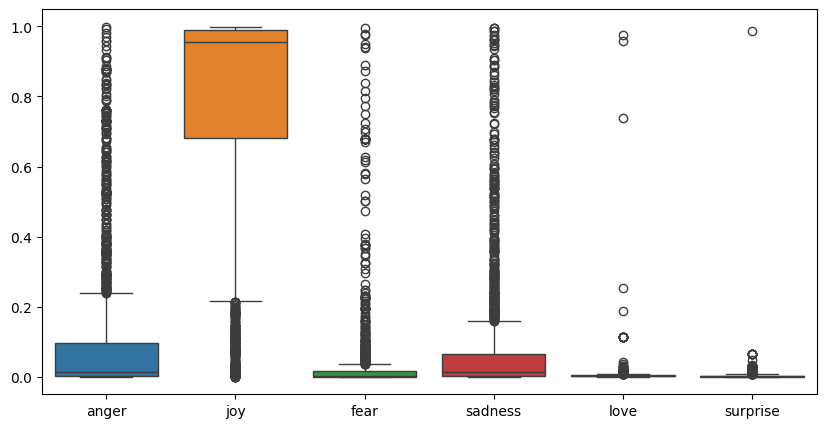

In [18]:
# Look for outliers in emotions of ubs_prepared_data
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize outliers of last 6 columns (emotions) using boxplots
# Display as vertical boxes on the same plot
plt.figure(figsize=(10, 5))
sns.boxplot(data=ubs_prepared_data.iloc[:, -6:])
plt.show()


There are some significant outliers in the data for all the emotions. Hence use the median rather than the mean

### Presentation Section

In [19]:
# Create dataframe to calculate median and standard deviation of every emotion every quarter (UBS)
ubs_prepared_emotion_stats = ubs_prepared_data.groupby(["quarter", "main_emotion"]).agg(
    median_score=("main_emotion_score", "median"),
    std_score=("main_emotion_score", "std")
    # if NaN values, replace with 0
).fillna(0).reset_index()
ubs_prepared_emotion_stats.head(10)

,quarter,main_emotion,median_score,std_score
0,2023-Q1,anger,0.708872,0.194897
1,2023-Q1,fear,0.941451,0.228856
2,2023-Q1,joy,0.967801,0.135048
3,2023-Q1,sadness,0.547714,0.118052
4,2023-Q2,anger,0.674059,0.181752
5,2023-Q2,fear,0.729220,0.125509
6,2023-Q2,joy,0.975933,0.146764
7,2023-Q2,sadness,0.551952,0.182249
8,2023-Q2,surprise,0.987155,0.000000
9,2023-Q3,anger,0.646491,0.142315


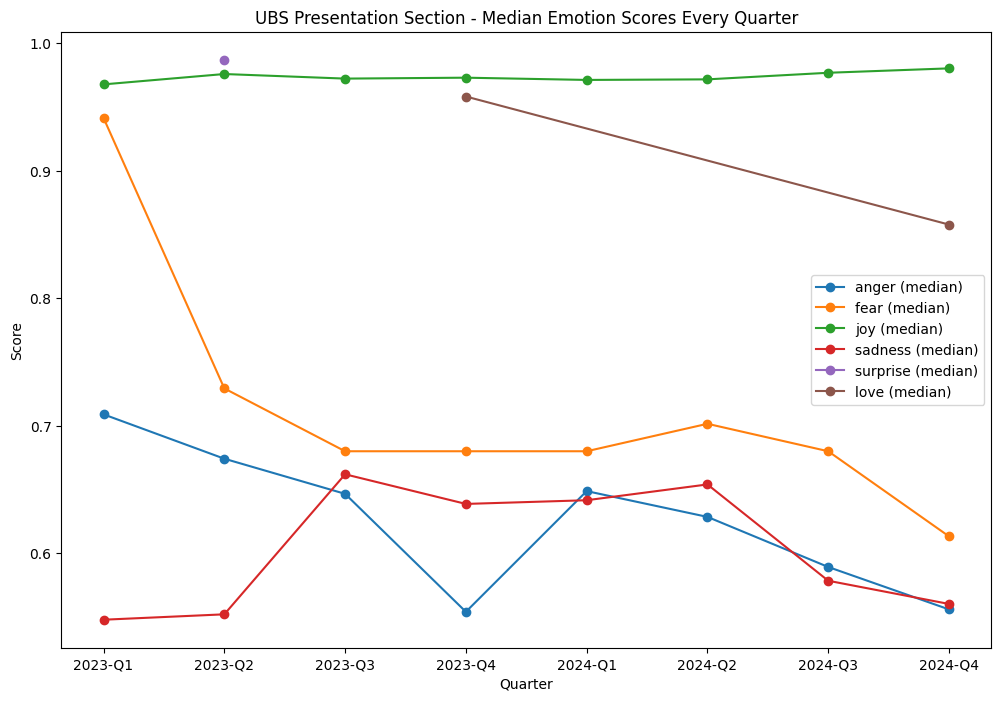

In [20]:
# Plot median for emotion every quarter as a scatter plot on the same plot (UBS)
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
for emotion in ubs_prepared_emotion_stats["main_emotion"].unique():
    ubs_emotion_prepared_data = ubs_prepared_emotion_stats[ubs_prepared_emotion_stats["main_emotion"] == emotion]
    plt.plot(ubs_emotion_prepared_data["quarter"], ubs_emotion_prepared_data["median_score"], label=f"{emotion} (median)", marker='o')
plt.title("UBS Presentation Section - Median Emotion Scores Every Quarter")
plt.xlabel("Quarter")
plt.ylabel("Score")
plt.legend()
plt.show()

### Q&A Section
Only those listed as Management who are answering the questions (not the questions themselves)

In [21]:
# Drop rows with speaker role = analyst
ubs_m_qa_data = ubs_qa_data[ubs_qa_data["speaker_role"] != "analyst"].reset_index(drop=True)

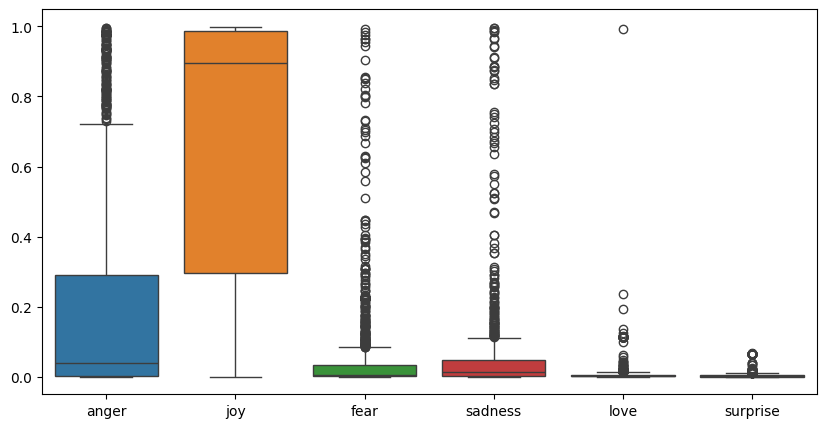

In [22]:
# Look for outliers in emotions of ubs_qa_data
# Visualize outliers of last 6 columns (emotions) using boxplots
# Display as vertical boxes on the same plot
plt.figure(figsize=(10, 5))
sns.boxplot(data=ubs_m_qa_data.iloc[:, -6:])
plt.show()

Again there are plenty of outliers - hence use the median rather than the mean

In [23]:
# Create dataframe to calculate median and standard deviation of every emotion every quarter (UBS)
ubs_m_qa_emotion_stats = ubs_m_qa_data.groupby(["quarter", "main_emotion"]).agg(
    median_score=("main_emotion_score", "median"),
    std_score=("main_emotion_score", "std")
    # if NaN values, replace with 0
).fillna(0).reset_index()
ubs_m_qa_emotion_stats.head(10)

,quarter,main_emotion,median_score,std_score
0,2023-Q1,anger,0.517480,0.251828
1,2023-Q1,fear,0.799631,0.169760
2,2023-Q1,joy,0.972941,0.138532
3,2023-Q1,sadness,0.665126,0.211810
4,2023-Q2,anger,0.522994,0.232792
5,2023-Q2,fear,0.963366,0.365154
6,2023-Q2,joy,0.963988,0.149697
7,2023-Q2,sadness,0.742615,0.182372
8,2023-Q3,anger,0.629993,0.252982
9,2023-Q3,fear,0.628433,0.151424


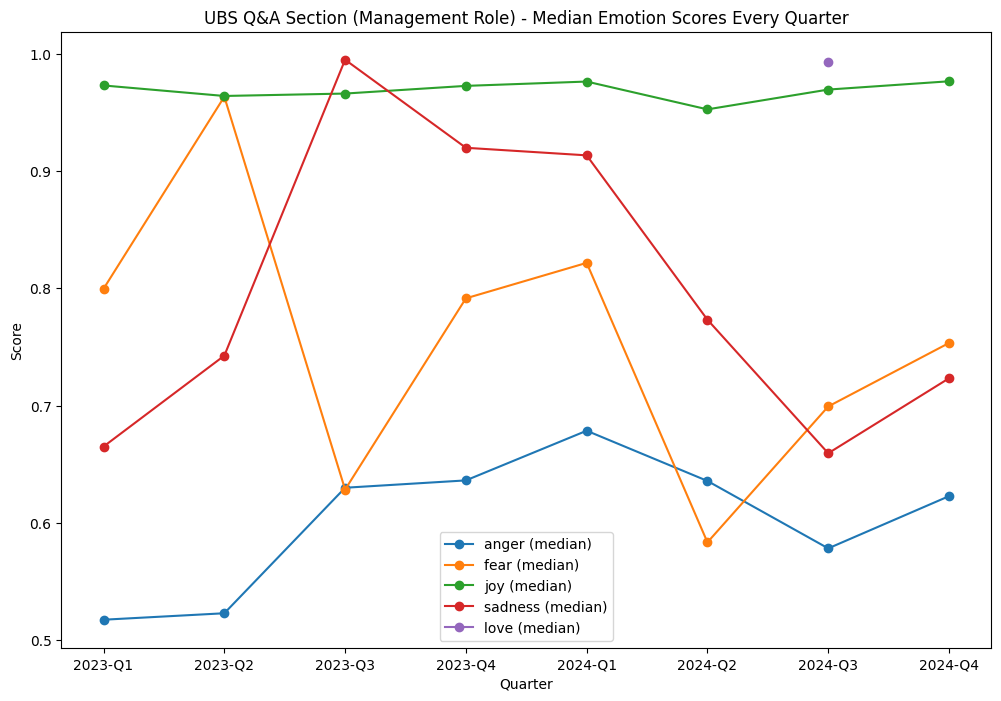

In [24]:
# Plot median for emotion every quarter as a scatter plot on the same plot (UBS) - Management role during Q&A
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
for emotion in ubs_m_qa_emotion_stats["main_emotion"].unique():
    ubs_emotion_m_qa_data = ubs_m_qa_emotion_stats[ubs_m_qa_emotion_stats["main_emotion"] == emotion]
    plt.plot(ubs_emotion_m_qa_data["quarter"], ubs_emotion_m_qa_data["median_score"], label=f"{emotion} (median)", marker='o')
plt.title("UBS Q&A Section (Management Role) - Median Emotion Scores Every Quarter")
plt.xlabel("Quarter")
plt.ylabel("Score")
plt.legend()
plt.show()

### Analysts
These show much more erratic changes in sentiment - presumablky due to the number of different question types

In [25]:
# Drop rows with speaker role = management
ubs_a_qa_data = ubs_qa_data[ubs_qa_data["speaker_role"] != "management"].reset_index(drop=True)

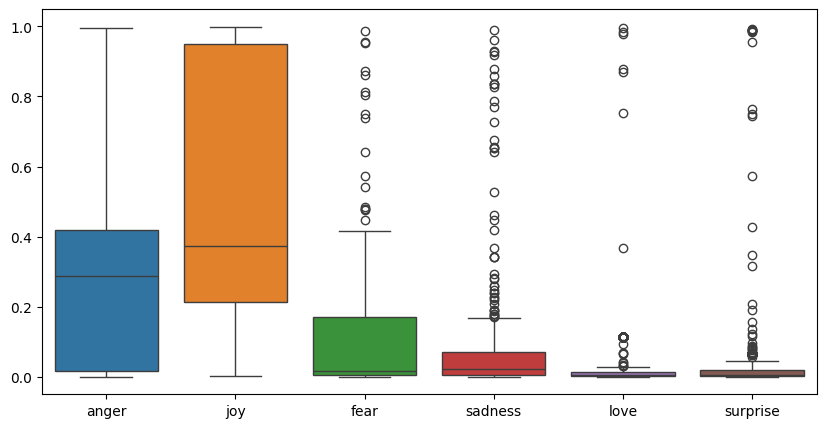

In [26]:
# Look for outliers in emotions of ubs_qa_data
# Visualize outliers of last 6 columns (emotions) using boxplots
# Display as vertical boxes on the same plot
plt.figure(figsize=(10, 5))
sns.boxplot(data=ubs_a_qa_data.iloc[:, -6:])
plt.show()

Less outliers with "anger" and "joy" but full range of scores for "sadness", "fear", and "surprise" as outliers

In [27]:
# Create dataframe to calculate mean and standard deviation of every emotion every quarter (UBS)
ubs_a_qa_emotion_stats = ubs_a_qa_data.groupby(["quarter", "main_emotion"]).agg(
    median_score=("main_emotion_score", "median"),
    std_score=("main_emotion_score", "std")
    # if NaN values, replace with 0
).fillna(0).reset_index()
ubs_a_qa_emotion_stats.head(10)

,quarter,main_emotion,median_score,std_score
0,2023-Q1,anger,0.525131,0.273043
1,2023-Q1,fear,0.431263,0.068204
2,2023-Q1,joy,0.965408,0.153113
3,2023-Q1,love,0.870791,0.000000
4,2023-Q1,sadness,0.790655,0.195292
5,2023-Q1,surprise,0.750671,0.281027
6,2023-Q2,anger,0.623653,0.278277
7,2023-Q2,fear,0.642580,0.000000
8,2023-Q2,joy,0.959069,0.146441
9,2023-Q2,sadness,0.652688,0.110772


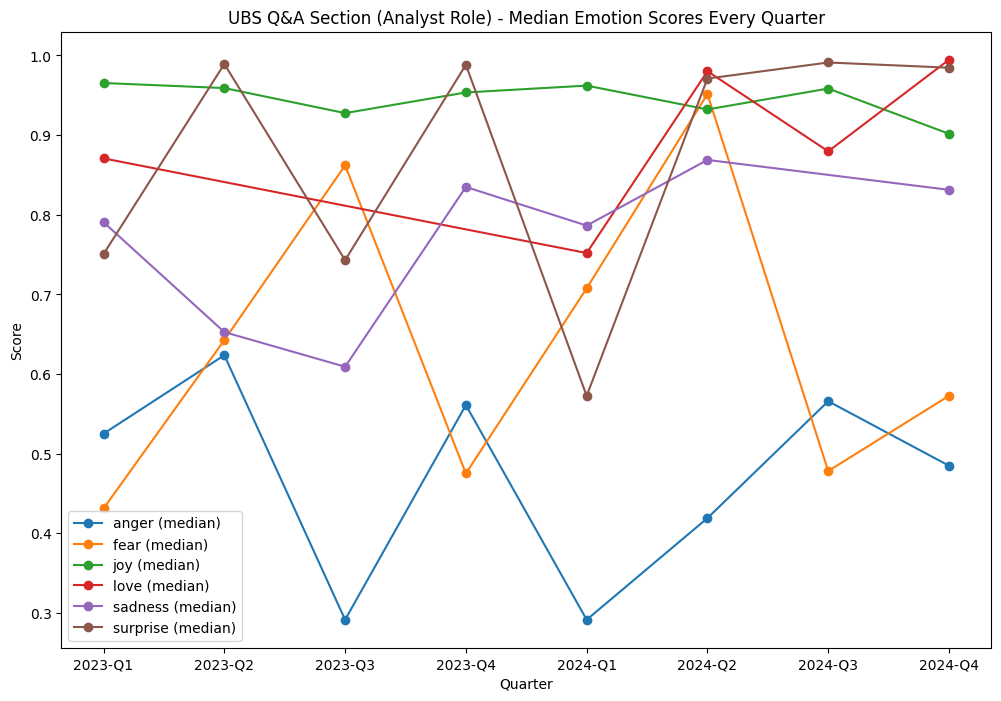

In [28]:
# Plot median for emotion every quarter as a scatter plot on the same plot (UBS) - Management role during Q&A
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
for emotion in ubs_a_qa_emotion_stats["main_emotion"].unique():
    ubs_emotion_a_qa_data = ubs_a_qa_emotion_stats[ubs_a_qa_emotion_stats["main_emotion"] == emotion]
    plt.plot(ubs_emotion_a_qa_data["quarter"], ubs_emotion_a_qa_data["median_score"], label=f"{emotion} (median)", marker='o')
plt.title("UBS Q&A Section (Analyst Role) - Median Emotion Scores Every Quarter")
plt.xlabel("Quarter")
plt.ylabel("Score")
plt.legend()
plt.show()

## Find differences between Presentation and Q&A (Management roles)

In [29]:
# Create one dataframe from ubs_prepared_emotion_stats and ubs_qa_filtered_emotion_stats for comparison plots and retain column for prepared vs Q&A
ubs_comparison_emotion_stats = pd.concat([
    ubs_prepared_emotion_stats.assign(source="prepared"),
    ubs_m_qa_emotion_stats.assign(source="Q&A")
]).reset_index(drop=True)
ubs_comparison_emotion_stats.head(10)

,quarter,main_emotion,median_score,std_score,source
0,2023-Q1,anger,0.708872,0.194897,prepared
1,2023-Q1,fear,0.941451,0.228856,prepared
2,2023-Q1,joy,0.967801,0.135048,prepared
3,2023-Q1,sadness,0.547714,0.118052,prepared
4,2023-Q2,anger,0.674059,0.181752,prepared
5,2023-Q2,fear,0.729220,0.125509,prepared
6,2023-Q2,joy,0.975933,0.146764,prepared
7,2023-Q2,sadness,0.551952,0.182249,prepared
8,2023-Q2,surprise,0.987155,0.000000,prepared
9,2023-Q3,anger,0.646491,0.142315,prepared


In [30]:
ubs_comparison_emotion_stats.tail(10)

,quarter,main_emotion,median_score,std_score,source
58,2024-Q2,sadness,0.773237,0.143153,Q&A
59,2024-Q3,anger,0.578303,0.250393,Q&A
60,2024-Q3,fear,0.699286,0.235846,Q&A
61,2024-Q3,joy,0.969441,0.150034,Q&A
62,2024-Q3,love,0.992780,0.000000,Q&A
63,2024-Q3,sadness,0.659390,0.161140,Q&A
64,2024-Q4,anger,0.622819,0.257613,Q&A
65,2024-Q4,fear,0.753384,0.210513,Q&A
66,2024-Q4,joy,0.976505,0.156684,Q&A
67,2024-Q4,sadness,0.723312,0.195343,Q&A


### Plot option 1: Subtracting Presentation from Q&A
Any increase is due to the Q&A section having greater emotion score than the presentation section (e.g. Q2 2023 increase in fear from the takeover and Q3 & Q4 2023 increase in sadness from the Q&A)

In [31]:
# Find the difference between Q&A and prepared mean scores for each emotion and quarter
ubs_diff_emotion_stats = ubs_comparison_emotion_stats.pivot_table(
    index=["quarter", "main_emotion"],
    columns="source",
    values="median_score",
    # if NaN values, replace with 0
    fill_value=0,
).reset_index()
ubs_diff_emotion_stats["diff"] = ubs_diff_emotion_stats["Q&A"] - ubs_diff_emotion_stats["prepared"]
ubs_diff_emotion_stats.head(10)


source,quarter,main_emotion,Q&A,prepared,diff
0,2023-Q1,anger,0.517480,0.708872,-0.191393
1,2023-Q1,fear,0.799631,0.941451,-0.141820
2,2023-Q1,joy,0.972941,0.967801,0.005141
3,2023-Q1,sadness,0.665126,0.547714,0.117411
4,2023-Q2,anger,0.522994,0.674059,-0.151066
5,2023-Q2,fear,0.963366,0.729220,0.234146
6,2023-Q2,joy,0.963988,0.975933,-0.011945
7,2023-Q2,sadness,0.742615,0.551952,0.190664
8,2023-Q2,surprise,0.000000,0.987155,-0.987155
9,2023-Q3,anger,0.629993,0.646491,-0.016498


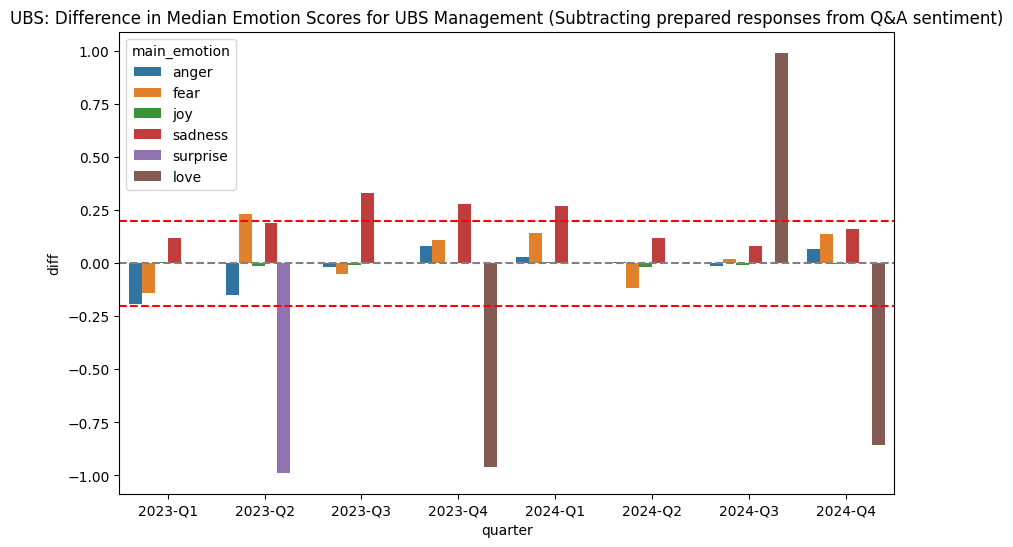

In [32]:
# Display the combined emotion stats for UBS Q&A and prepared data as a bar plot
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(data=ubs_diff_emotion_stats, x="quarter", y="diff", hue="main_emotion")
plt.axhline(0, linestyle='--', color='gray')
# Add axis line for 20% change in emotion scores
plt.axhline(0.2, linestyle='--', color='red')
plt.axhline(-0.2, linestyle='--', color='red')
plt.title("UBS: Difference in Median Emotion Scores for UBS Management (Subtracting prepared responses from Q&A sentiment)")
plt.show()

###  Plot option 2: Subtracting Q&A from Presentation sections
Any increase is due to the presentation section having greater emotion score than the Q&A section (e.g. Q2 2023 was the merge announcement - hence increase in surprise)

In [33]:
# Find the difference between Q&A and prepared mean scores for each emotion and quarter
ubs_diff2_emotion_stats = ubs_comparison_emotion_stats.pivot_table(
    index=["quarter", "main_emotion"],
    columns="source",
    values="median_score",
    # if NaN values, replace with 0
    fill_value=0,
).reset_index()
ubs_diff2_emotion_stats["diff"] = ubs_diff2_emotion_stats["prepared"] - ubs_diff2_emotion_stats["Q&A"]
ubs_diff2_emotion_stats.head(10)

source,quarter,main_emotion,Q&A,prepared,diff
0,2023-Q1,anger,0.517480,0.708872,0.191393
1,2023-Q1,fear,0.799631,0.941451,0.141820
2,2023-Q1,joy,0.972941,0.967801,-0.005141
3,2023-Q1,sadness,0.665126,0.547714,-0.117411
4,2023-Q2,anger,0.522994,0.674059,0.151066
5,2023-Q2,fear,0.963366,0.729220,-0.234146
6,2023-Q2,joy,0.963988,0.975933,0.011945
7,2023-Q2,sadness,0.742615,0.551952,-0.190664
8,2023-Q2,surprise,0.000000,0.987155,0.987155
9,2023-Q3,anger,0.629993,0.646491,0.016498


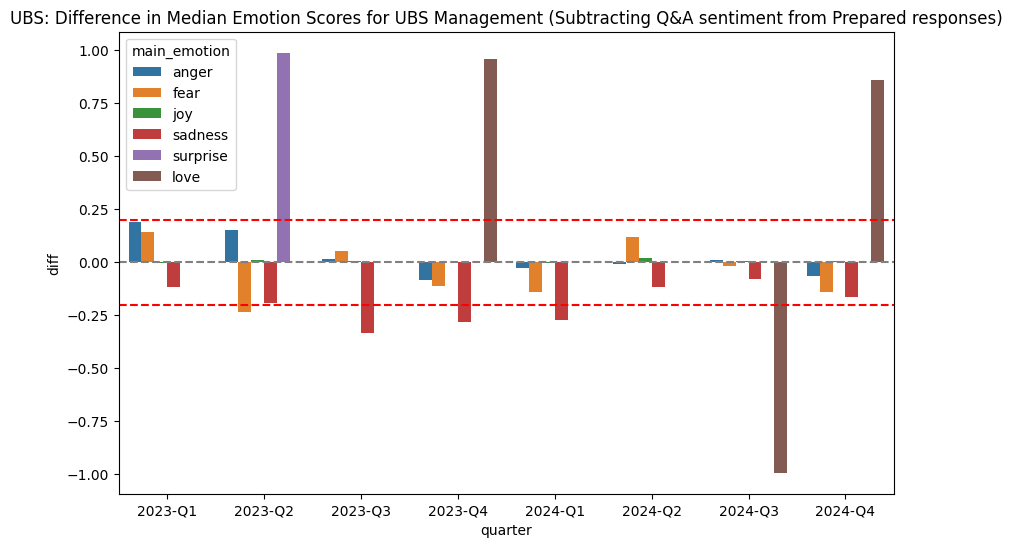

In [34]:
# Display the combined emotion stats for UBS Q&A and prepared data as a bar plot
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(data=ubs_diff2_emotion_stats, x="quarter", y="diff", hue="main_emotion")
plt.axhline(0, linestyle='--', color='gray')
# Add axis line for 20% change in emotion scores
plt.axhline(0.2, linestyle='--', color='red')
plt.axhline(-0.2, linestyle='--', color='red')
plt.title("UBS: Difference in Median Emotion Scores for UBS Management (Subtracting Q&A sentiment from Prepared responses)")
plt.show()

## Final timeline (UBS) - Emotions

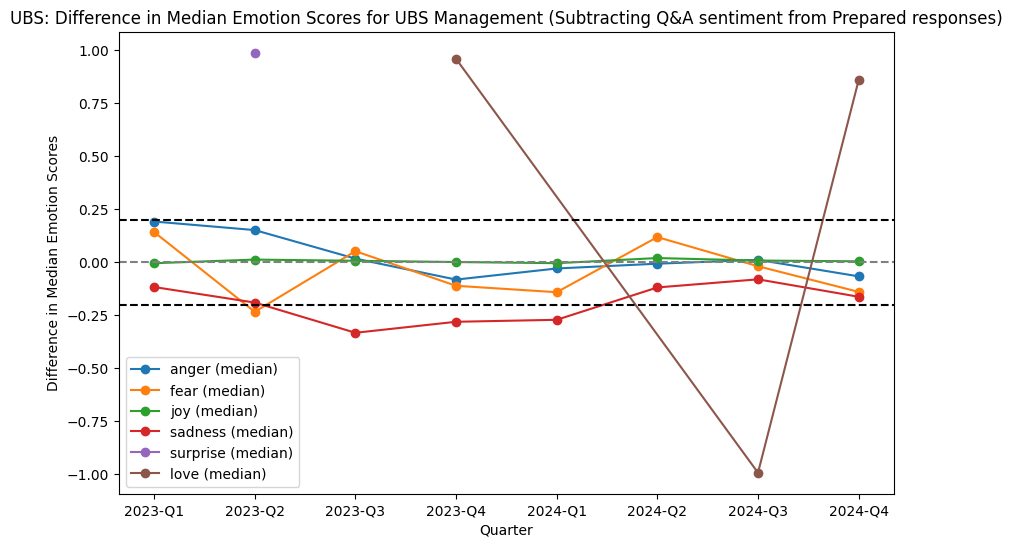

In [35]:
# Plot as line graph
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
for emotion in ubs_diff2_emotion_stats["main_emotion"].unique():
    emotion_data = ubs_diff2_emotion_stats[ubs_diff2_emotion_stats["main_emotion"] == emotion]
    plt.plot(emotion_data["quarter"], emotion_data["diff"], label=f"{emotion} (median)", marker='o')
plt.axhline(0, linestyle='--', color='gray')
plt.axhline(0.2, linestyle='--', color='black')
plt.axhline(-0.2, linestyle='--', color='black')
plt.title("UBS: Difference in Median Emotion Scores for UBS Management (Subtracting Q&A sentiment from Prepared responses)")
plt.xlabel("Quarter")
plt.ylabel("Difference in Median Emotion Scores")
plt.legend()
# Save figure
plt.savefig("BertEmotion_UBS_timeline.png")
plt.show()


## Final summary
Not sure which is the best way to present this:  

Significant changes are:  

When using MEAN:  
* Surprise in Q2 2023 (sentiment higher in presentation than Q&A)
* Sadness in Q3 2023 (lower in Q&A than presentation). 
* Love in Q4 2023 (higher in Q&A than presentation). 
* Fear in Q2 2024 (higher in Q&A than presentation).
* Love oscillating Q3 and Q4 2024

---


When using MEDIAN: 

**Q2 2023**
* Surprise higher in presentation than Q&A.
* Fear lower in presentation than Q&A. 

**Q3 2023**
* Sadness lower in Q&A than presentation. 

**Q4 2023**
* Sadness lower in Q&A than presentation. 
* Love higher in Q&A than presentation. 

**Q1 2024**
* Sadness lower in Q&A than presentation. 

**Q3 & Q4 2024**
* Love oscillating from lower in Q&A than presentation to the opposite in Q4
